# Feature Evaluation: Qualitative Dimension Analysis vs. Numeric Prediction

This notebook evaluates the performance of Gemini 3.1 Flash lite in understanding the qualitative drivers of YouTube video performance. It specifically tests how well the LLM can identify the contribution of specific semantic dimensions to a video's popularity and compares these insights against numeric ground truth from OLS models.

## Analysis Structure:
1. **Methodology**: Description of data sources, label mappings, and evaluation metrics.
2. **Result 1: Ordered Label Accuracy**: Evaluates how accurately the LLM labels semantic dimension contributions using an ordered 7-point scale.
3. **Result 2: Numeric Prediction Accuracy**: Compares LLM log-view predictions against actual views and OLS benchmarks.
4. **Main Result: Qualitative-Quantitative Correlation**: The core hypothesis—testing if better qualitative understanding (labeling) leads to better quantitative accuracy (prediction) at a **video level**.
5. **Segmented Analysis**: Performance across different video performance brackets (tails vs. center).

## 1. Setup and Dependencies

In [2]:
!pip install -q -U google-generativeai

import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive, userdata
import google.generativeai as genai
from datetime import datetime
from sklearn.metrics import mean_absolute_error, r2_score, confusion_matrix
from scipy import stats

# Mount Google Drive
drive.mount('/content/drive')

# Configure Gemini
# Note: gemini-3.1-flash-lite-latest is used as specified in project memory and instructions
GEMINI_API_KEY = userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=GEMINI_API_KEY)
MODEL_NAME = 'gemini-3.1-flash-lite'

# Constants
BASE_PATH = '/content/drive/MyDrive/numeric_inference_outputs/'
EVAL_DATA_FILE = os.path.join(BASE_PATH, 'top_significant_channels_eval.json')
LLM_ANALYSIS_FILE = os.path.join(BASE_PATH, 'llm_analysis_results.json')
OUTPUT_FILE = os.path.join(BASE_PATH, 'feature_evaluation_results.json')
CACHE_FILE = os.path.join(BASE_PATH, 'feature_eval_cache.json')

Mounted at /content/drive


## 2. Methodology and Data Preprocessing

### Data Sources
- **Top Significant Channels**: A dataset of 10 channels with the most statistically significant OLS models.
- **LLM Analysis Results**: Qualitative definitions of PCA dimensions and channel success drivers generated in the pipeline.

### Ordered Label Mapping
We use a 7-point scale for dimension contribution. Unlike categorical classification, these labels are ordered, meaning a mistake between "positive" and "extremely positive" is less severe than a mistake between "positive" and "negative".

| Label | Value |
| :--- | :---: |
| extremely negative | -3 |
| negative | -2 |
| mildly negative | -1 |
| neutral | 0 |
| mildly positive | 1 |
| positive | 2 |
| extremely positive | 3 |

### Ground Truth Labeling
Ground truth labels are calculated by mapping the actual contribution of a dimension (coefficient * embedding value) to the training distribution percentiles: 5%, 15%, 35%, 65%, 85%, 95%.

In [3]:
with open(EVAL_DATA_FILE, 'r') as f:
    eval_dataset = json.load(f)

with open(LLM_ANALYSIS_FILE, 'r') as f:
    llm_analysis = json.load(f)

LABEL_ORDER = [
    "extremely negative", "negative", "mildly negative",
    "neutral",
    "mildly positive", "positive", "extremely positive"
]

LABEL_TO_VAL = {l: i - 3 for i, l in enumerate(LABEL_ORDER)}

DISTRIBUTION = [0.05, 0.10, 0.20, 0.30, 0.20, 0.10, 0.05]
CUMULATIVE_DIST = np.cumsum(DISTRIBUTION)

def get_channel_stats(train_videos):
    log_views = np.log1p([v['actual_views'] for v in train_videos])
    return {
        'min': float(np.min(log_views)),
        'max': float(np.max(log_views)),
        'mean': float(np.mean(log_views)),
        'q1': float(np.percentile(log_views, 25)),
        'median': float(np.median(log_views)),
        'q3': float(np.percentile(log_views, 75))
    }

def get_dimension_thresholds(channel_data):
    train_vids = channel_data['train_videos']
    coeffs = channel_data['model']['coefficients']
    p_values = np.array(channel_data['model']['p_values'][1:])
    sig_indices = np.argsort(p_values)[:5]

    thresholds = {}
    for idx in sig_indices:
        coeff = coeffs[idx]
        # Calculate contribution: coeff * embedding_value
        contributions = [coeff * v['reduced_embedding'][idx] for v in train_vids]

        # Percentiles for the thresholds
        t_vals = [np.percentile(contributions, p * 100) for p in CUMULATIVE_DIST[:-1]]
        thresholds[int(idx)] = t_vals

    return thresholds, sig_indices

channel_info = {}
for c in eval_dataset:
    cid = c['channel_id']
    stats_dict = get_channel_stats(c['train_videos'])
    thresh, sig_idx = get_dimension_thresholds(c)
    channel_info[cid] = {
        'stats': stats_dict,
        'thresholds': thresh,
        'sig_indices': sig_idx
    }

print(f"Processed {len(eval_dataset)} channels.")

Processed 10 channels.


## 3. Utility Functions

In [4]:
def load_cache():
    if os.path.exists(CACHE_FILE):
        with open(CACHE_FILE, 'r') as f:
            return json.load(f)
    return {}

def save_cache(cache):
    with open(CACHE_FILE, 'w') as f:
        json.dump(cache, f, indent=4)

def get_gemini_completion(prompt, cache, key, retries=3, sleep_time=2):
    if key in cache:
        return cache[key]

    model = genai.GenerativeModel(MODEL_NAME)

    for i in range(retries):
        try:
            response = model.generate_content(prompt)
            text = response.text
            cache[key] = text
            save_cache(cache)
            time.sleep(sleep_time)
            return text
        except Exception as e:
            print(f"Error on attempt {i+1}: {e}")
            if i < retries - 1:
                time.sleep(sleep_time * (i + 1))
            else:
                raise e
    return None

def parse_json_response(text):
    import re
    try:
        # Strip markdown
        text = re.sub(r'```json\s*', '', text)
        text = re.sub(r'```\s*', '', text)
        # Find JSON block
        match = re.search(r'\[.*\]', text, re.DOTALL)
        if match:
            return json.loads(match.group())
    except:
        pass
    return None

## 4. Inference Engine

We batch the test videos (10 per request) to maximize context efficiency. For each video, the LLM is provided with:
1. Global channel success drivers.
2. Qualitative analysis of significant dimensions.
3. Precise definitions for the dimensions being evaluated.
4. Statistical benchmarks (min/max/average log views) from the training set.

In [5]:
cache = load_cache()
all_results = []

def get_ground_truth_label(contribution, thresholds):
    for idx, t in enumerate(thresholds):
        if contribution <= t:
            return LABEL_ORDER[idx]
    return LABEL_ORDER[-1]

for channel in eval_dataset:
    cid = channel['channel_id']
    cname = channel['channel_name']
    info = channel_info[cid]
    stats_vals = info['stats']
    sig_indices = info['sig_indices']
    thresholds = info['thresholds']
    coeffs = channel['model']['coefficients']

    # Context from llm-pipeline
    global_desc = llm_analysis['global_performance_descriptions'].get(cid, "")
    dim_analysis = llm_analysis['channel_significant_dimension_analysis'].get(cid, "")
    dim_definitions = [llm_analysis['dimension_definitions'][idx] for idx in sig_indices]

    test_vids = channel['test_videos']
    channel_results = []

    for i in range(0, len(test_vids), 10):
        batch = test_vids[i:i+10]
        titles = "\n".join([f"- {v['title']}" for v in batch])
        batch_titles_lower = [v['title'].lower() for v in batch]

        dim_info_str = "\n".join([f"Dimension {idx}: {desc}" for idx, desc in zip(sig_indices, dim_definitions)])

        prompt = f"""You are a YouTube performance analyst.
Channel: {cname}
Success Drivers: {global_desc}
Significant Dimension Analysis: {dim_analysis}

Semantic Dimensions to evaluate:
{dim_info_str}

Training Data Stats (Logarithmic Views):
- Min: {stats_vals['min']:.2f}
- Max: {stats_vals['max']:.2f}
- Average: {stats_vals['mean']:.2f}
- Q1: {stats_vals['q1']:.2f}
- Median: {stats_vals['median']:.2f}
- Q3: {stats_vals['q3']:.2f}

Task: For each of the following video titles, evaluate how each of the 5 dimensions contributes and predict the logarithmic views.
Labels for dimension contribution: "extremely positive", "positive", "mildly positive", "neutral", "mildly negative", "negative", "extremely negative".
Expected distribution: extremely +/- (5%), +/- (10%), mildly +/- (20%), neutral (30%).

Return ONLY a JSON list of objects, one for each video:
[{{
  "title": "video title",
  "dimension_evaluations": {{ "{sig_indices[0]}": "label", "{sig_indices[1]}": "label", ... }},
  "predicted_log_views": numeric_value
}}, ...]

Titles:
{titles}
"""

        res_text = get_gemini_completion(prompt, cache, f"feature_eval_{cid}_batch_{i//10}")
        batch_data = parse_json_response(res_text)

        if batch_data:
            for obj in batch_data:
                if 'title' in obj and 'dimension_evaluations' in obj and 'predicted_log_views' in obj:
                    title_lower = str(obj['title']).lower()
                    if title_lower in batch_titles_lower:
                        idx_in_batch = batch_titles_lower.index(title_lower)

                        # Normalize labels
                        cleaned_evals = {}
                        for k, v in obj['dimension_evaluations'].items():
                            clean_v = str(v).lower().replace('positively', 'positive').replace('negatively', 'negative')
                            cleaned_evals[k] = clean_v

                        labels_ok = all(v in LABEL_TO_VAL for v in cleaned_evals.values())
                        if labels_ok:
                            # Add ground truth and metadata
                            v_orig = batch[idx_in_batch]
                            obj['dimension_evaluations'] = cleaned_evals
                            obj['video_id'] = v_orig['video_id']
                            obj['actual_log_views'] = np.log1p(v_orig['actual_views'])
                            obj['numeric_prediction'] = np.log1p(v_orig['predicted_views'])
                            obj['reduced_embedding'] = v_orig['reduced_embedding']
                            
                            # Calculate Label Accuracy for this video
                            label_errors = []
                            for dim_str, pred_label in cleaned_evals.items():
                                d_idx = int(dim_str)
                                contribution = coeffs[d_idx] * v_orig['reduced_embedding'][d_idx]
                                gt_label = get_ground_truth_label(contribution, thresholds[d_idx])
                                error = abs(LABEL_TO_VAL[gt_label] - LABEL_TO_VAL[pred_label])
                                label_errors.append(error)
                            
                            obj['mean_label_error'] = np.mean(label_errors)
                            channel_results.append(obj)

    all_results.append({
        'channel_id': cid,
        'channel_name': cname,
        'results': channel_results
    })

print(f"Generated results for {sum(len(c['results']) for c in all_results)} videos.")

Generated results for 968 videos.


## 5. Result 1: Ordered Label Accuracy

**Hypothesis**: The LLM can identify the relative contribution of semantic dimensions. Since labels are ordered, we evaluate performance based on the distance between the predicted label rank and ground truth rank.

**Methodology**:
- **Exact Match**: Predicted label == Ground truth label.
- **Neighbor Match**: Predicted label is within 1 step of ground truth (e.g., predicted "positive" for ground truth "extremely positive").
- **Mean Absolute Label Error (MALE)**: Average rank distance (0-6 scale) between prediction and ground truth.

--- GLOBAL LABEL ACCURACY ---
Mean Absolute Label Error (MALE): 1.546 ranks
Exact Match Accuracy: 20.8%
Neighbor Accuracy (within 1 rank): 55.0%


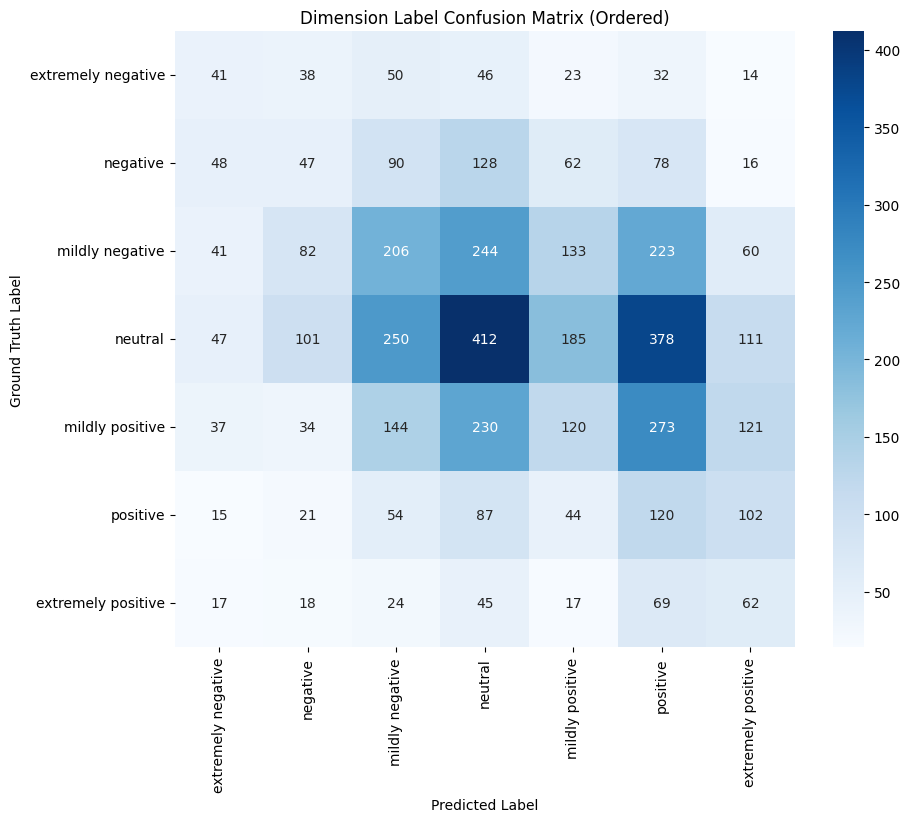

In [6]:
def get_ground_truth_label(contribution, thresholds):
    for idx, t in enumerate(thresholds):
        if contribution <= t:
            return LABEL_ORDER[idx]
    return LABEL_ORDER[-1]

analysis_rows = []
all_gt_labels = []
all_pred_labels = []

for channel_res in all_results:
    cid = channel_res['channel_id']
    cname = channel_res['channel_name']
    info = channel_info[cid]
    thresholds = info['thresholds']
    coeffs = next(c for c in eval_dataset if c['channel_id'] == cid)['model']['coefficients']

    for res in channel_res['results']:
        emb = res['reduced_embedding']
        label_distances = []
        matches = 0
        neighbor_matches = 0

        for dim_str, pred_label in res['dimension_evaluations'].items():
            dim_idx = int(dim_str)
            contribution = coeffs[dim_idx] * emb[dim_idx]
            gt_label = get_ground_truth_label(contribution, thresholds[dim_idx])

            gt_val = LABEL_TO_VAL[gt_label]
            pred_val = LABEL_TO_VAL[pred_label]

            dist = abs(gt_val - pred_val)
            label_distances.append(dist)

            if dist == 0: matches += 1
            if dist <= 1: neighbor_matches += 1

            all_gt_labels.append(gt_label)
            all_pred_labels.append(pred_label)

        mean_label_dist = np.mean(label_distances)
        pred_error = abs(res['predicted_log_views'] - res['actual_log_views'])

        analysis_rows.append({
            'channel': cname,
            'mean_label_error': mean_label_dist,
            'exact_match_acc': matches / 5,
            'neighbor_acc': neighbor_matches / 5,
            'prediction_error': pred_error,
            'actual_log_views': res['actual_log_views'],
            'predicted_log_views': res['predicted_log_views'],
            'numeric_prediction': res['numeric_prediction'],
            'mean_log_views': info['stats']['mean'],
            'q1': info['stats']['q1'],
            'q3': info['stats']['q3']
        })

df_analysis = pd.DataFrame(analysis_rows)

print("--- GLOBAL LABEL ACCURACY ---")
print(f"Mean Absolute Label Error (MALE): {df_analysis['mean_label_error'].mean():.3f} ranks")
print(f"Exact Match Accuracy: {df_analysis['exact_match_acc'].mean():.1%}")
print(f"Neighbor Accuracy (within 1 rank): {df_analysis['neighbor_acc'].mean():.1%}")

# Confusion Matrix Heatmap
plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_gt_labels, all_pred_labels, labels=LABEL_ORDER)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER, cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('Ground Truth Label')
plt.title('Dimension Label Confusion Matrix (Ordered)')
plt.show()

### Interpretation of Label Accuracy

- **Diagonal Concentration**: High density along the diagonal indicates strong qualitative alignment.
- **MALE Metric**: Represents the average distance from ground truth. A MALE below 1.0 indicates that the model is, on average, within one neighbor of the correct label.
- **Off-Diagonal Spread**: Clusters far from the diagonal suggest systemic misunderstandings of specific dimensions (e.g., confusing extremely positive with neutral).

Global LLM MAE: 1.042
Global OLS MAE: 0.923


/tmp/ipykernel_3474/3750644864.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  channel_metrics = df_analysis.groupby('channel').apply(lambda x: pd.Series({


<Figure size 1200x600 with 0 Axes>

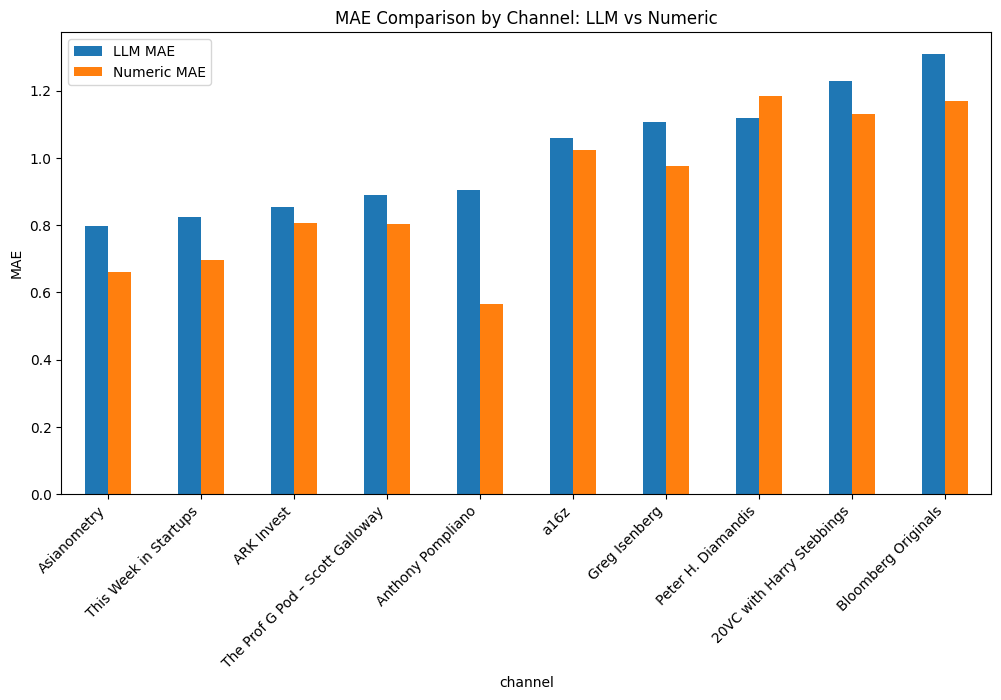

In [7]:
llm_mae = mean_absolute_error(df_analysis['actual_log_views'], df_analysis['predicted_log_views'])
ols_mae = mean_absolute_error(df_analysis['actual_log_views'], df_analysis['numeric_prediction'])

print(f"Global LLM MAE: {llm_mae:.3f}")
print(f"Global OLS MAE: {ols_mae:.3f}")

plt.figure(figsize=(12, 6))
channel_metrics = df_analysis.groupby('channel').apply(lambda x: pd.Series({
    'LLM MAE': mean_absolute_error(x['actual_log_views'], x['predicted_log_views']),
    'Numeric MAE': mean_absolute_error(x['actual_log_views'], x['numeric_prediction'])
})).sort_values('LLM MAE')
channel_metrics.plot(kind='bar', figsize=(12,6))
plt.title("MAE Comparison by Channel: LLM vs Numeric")
plt.ylabel("MAE")
plt.xticks(rotation=45, ha='right')
plt.show()

## 7. Main Result: Qualitative-Quantitative Correlation

**Hypothesis**: The accuracy of the qualitative labeling (understanding of dimensions) is a significant predictor of numeric prediction accuracy at the **video level**.

**Methodology**: We correlate the `Mean Label Error` (MALE) of each video with its `View Prediction Error` (Absolute error in log-views).

Global Correlation (Video Level): 0.1187 (p=2.146e-04)


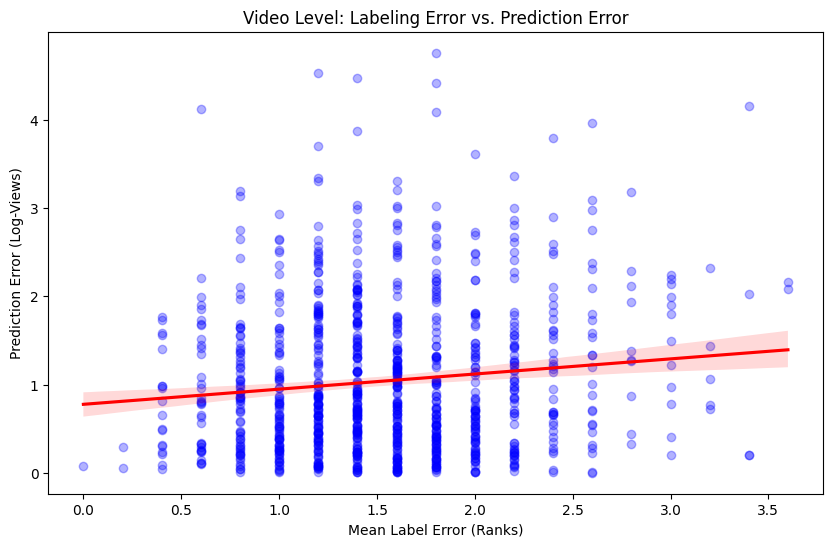

In [8]:
corr, pval = stats.pearsonr(df_analysis['mean_label_error'], df_analysis['prediction_error'])
print(f"Global Correlation (Video Level): {corr:.4f} (p={pval:.3e})")

plt.figure(figsize=(10, 6))
sns.regplot(data=df_analysis, x='mean_label_error', y='prediction_error',
            scatter_kws={'alpha':0.3, 'color':'blue'}, line_kws={'color':'red'})
plt.title("Video Level: Labeling Error vs. Prediction Error")
plt.xlabel("Mean Label Error (Ranks)")
plt.ylabel("Prediction Error (Log-Views)")
plt.show()

### Interpretation of Main Result

- **Positive Correlation**: This is the expected result. It indicates that the LLM's "reasoning" is consistent: when it fails to recognize the semantic factors (high labeling error), it also fails to predict the views accurately.
- **Slope of Regression**: Shows the sensitivity of quantitative predictions to qualitative insights. A steeper slope means that identifying dimensions correctly is critical for accurate performance prediction.

## 8. Segmented Analysis: Tails vs. Center

We evaluate if the LLM is more accurate at predicting and labeling videos that perform in the "tails" (outliers) versus the average center of the distribution.

,prediction_error,mean_label_error,exact_match_acc
is_tail,,,
Distribution Center,1.030490,1.524248,0.215230
Distribution Tails (Outliers),1.054966,1.569723,0.200853


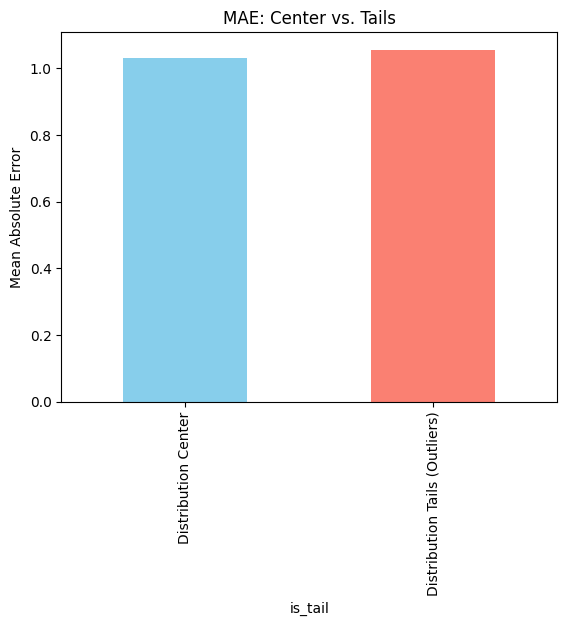

In [9]:
df_analysis['is_tail'] = (df_analysis['actual_log_views'] < df_analysis['q1']) | (df_analysis['actual_log_views'] > df_analysis['q3'])

tail_metrics = df_analysis.groupby('is_tail').agg({
    'prediction_error': 'mean',
    'mean_label_error': 'mean',
    'exact_match_acc': 'mean'
}).rename(index={False: 'Distribution Center', True: 'Distribution Tails (Outliers)'})

display(tail_metrics)

tail_metrics['prediction_error'].plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("MAE: Center vs. Tails")
plt.ylabel("Mean Absolute Error")
plt.show()

## 9. Summary Table by Channel

In [10]:
channel_summary = df_analysis.groupby('channel').agg({
    'mean_label_error': 'mean',
    'exact_match_acc': 'mean',
    'prediction_error': 'mean'
}).rename(columns={
    'mean_label_error': 'Label Error (Ranks)',
    'exact_match_acc': 'Exact Match %',
    'prediction_error': 'Prediction MAE'
}).sort_values('Label Error (Ranks)')

display(channel_summary)

,Label Error (Ranks),Exact Match %,Prediction MAE
channel,,,
The Prof G Pod – Scott Galloway,1.280000,0.256667,0.890132
Peter H. Diamandis,1.333333,0.245833,1.118398
Bloomberg Originals,1.480303,0.216667,1.308768
Asianometry,1.503448,0.213793,0.797677
Greg Isenberg,1.510345,0.241379,1.105395
20VC with Harry Stebbings,1.545455,0.212500,1.227823
ARK Invest,1.560656,0.245902,0.853378
a16z,1.646575,0.169863,1.058934
This Week in Startups,1.654098,0.190164,0.823125


## 10. Export Results

In [11]:
with open(OUTPUT_FILE, 'w') as f:
    json.dump(all_results, f, indent=4)
print(f"Results exported to {OUTPUT_FILE}")

Results exported to /content/drive/MyDrive/numeric_inference_outputs/feature_evaluation_results.json
